In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
 
# =============================================================
# PROJECT 1 — California Housing Price Prediction
# Model: Linear Regression
# Dataset: California Housing (sklearn built-in)
# =============================================================
 
# ─────────────────────────────────────────────
# STEP 1: Load and Explore the Data
# ─────────────────────────────────────────────
 
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target  # Target: median house price in $100,000s
 
print("=" * 55)
print("STEP 1 — Data Overview")
print("=" * 55)
print(df.head())
print(f"\nData shape     : {df.shape}")
print(f"Total houses   : {len(df):,}")
print(f"Average price  : ${df['Price'].mean():.2f} × $100,000")
print(f"\nBasic Statistics:\n{df.describe().round(2)}")
 

STEP 1 — Data Overview
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Data shape     : (20640, 9)
Total houses   : 20,640
Average price  : $2.07 × $100,000

Basic Statistics:
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.

In [2]:
# ─────────────────────────────────────────────
# STEP 2: Remove Outliers
# Why: Extreme values in AveRooms distort the model and plots.
# We keep only rows where AveRooms is within a reasonable range.
# ─────────────────────────────────────────────
 
print("\n" + "=" * 55)
print("STEP 2 — Removing Outliers")
print("=" * 55)
 
before = len(df)
df = df[df['AveRooms'] < 20]   # Remove extreme room counts
df = df[df['AveBedrms'] < 10]  # Remove extreme bedroom counts
after = len(df)
 
print(f"Rows before cleaning : {before:,}")
print(f"Rows after cleaning  : {after:,}")
print(f"Rows removed         : {before - after:,}")


STEP 2 — Removing Outliers
Rows before cleaning : 20,640
Rows after cleaning  : 20,571
Rows removed         : 69


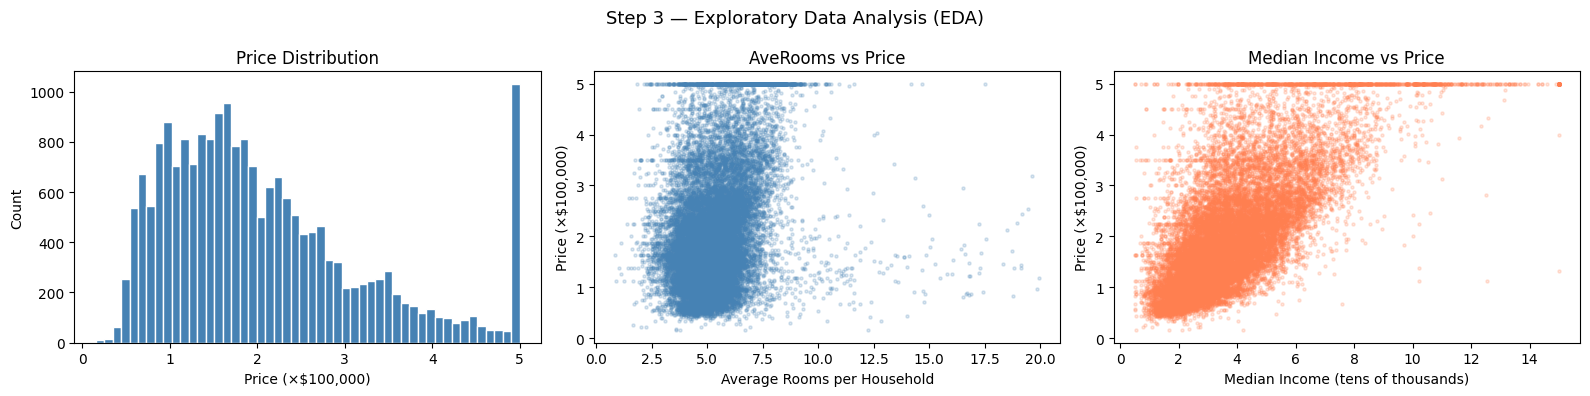

In [3]:
# ─────────────────────────────────────────────
# STEP 3: Exploratory Data Analysis (EDA)
# Why: Visualizing the data helps us understand distributions
# and relationships before building any model.
# ─────────────────────────────────────────────
 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Step 3 — Exploratory Data Analysis (EDA)", fontsize=13)
 
# Plot 1: Price Distribution
axes[0].hist(df['Price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("Price (×$100,000)")
axes[0].set_ylabel("Count")
 
# Plot 2: AveRooms vs Price
axes[1].scatter(df['AveRooms'], df['Price'], alpha=0.2, s=5, color='steelblue')
axes[1].set_title("AveRooms vs Price")
axes[1].set_xlabel("Average Rooms per Household")
axes[1].set_ylabel("Price (×$100,000)")
 
# Plot 3: MedInc vs Price (strongest feature)
axes[2].scatter(df['MedInc'], df['Price'], alpha=0.2, s=5, color='coral')
axes[2].set_title("Median Income vs Price")
axes[2].set_xlabel("Median Income (tens of thousands)")
axes[2].set_ylabel("Price (×$100,000)")
 
plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150)
plt.show()

In [4]:
# ─────────────────────────────────────────────
# STEP 4: Feature Selection & Data Splitting
# Why: We first use 4 features to understand their impact,
# then compare with using all 8 features.
# Train/Test split: 80% for training, 20% for testing.
# ─────────────────────────────────────────────
 
print("\n" + "=" * 55)
print("STEP 4 — Feature Selection & Data Splitting")
print("=" * 55)
 
features_4 = ['AveRooms', 'AveBedrms', 'Population', 'MedInc']
X = df[features_4]
y = df['Price']
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
 
print(f"Selected features    : {features_4}")
print(f"Training set size    : {X_train.shape}")
print(f"Test set size        : {X_test.shape}")
print("Note: random_state=42 ensures reproducible results every run.")


STEP 4 — Feature Selection & Data Splitting
Selected features    : ['AveRooms', 'AveBedrms', 'Population', 'MedInc']
Training set size    : (16456, 4)
Test set size        : (4115, 4)
Note: random_state=42 ensures reproducible results every run.


In [6]:
# ─────────────────────────────────────────────
# STEP 5: Train the Model (4 Features)
# The model learns the relationship: Price = w1*f1 + w2*f2 + ... + bias
# Coefficients (weights) show how much each feature affects the price.
# ─────────────────────────────────────────────
 
print("\n" + "=" * 55)
print("STEP 5 — Model Training (4 Features)")
print("=" * 55)
 
model = LinearRegression()
model.fit(X_train, y_train)

coef_df = pd.Series(model.coef_, index=features_4).round(4)
print("Model finished training!")
print(f"\nBias (Intercept)     : {model.intercept_:.4f}")
print("\nFeature Coefficients (weights):")
print(coef_df.to_string())
print("\nInterpretation:")
for feat, coef in zip(features_4, model.coef_):
    direction = "increases" if coef > 0 else "decreases"
    print(f"  • {feat:12s} → price {direction} by ${abs(coef):.4f} × $100,000 per unit increase")


STEP 5 — Model Training (4 Features)
Model finished training!

Bias (Intercept)     : 0.2818

Feature Coefficients (weights):
AveRooms     -0.3109
AveBedrms     1.2137
Population   -0.0000
MedInc        0.5703

Interpretation:
  • AveRooms     → price decreases by $0.3109 × $100,000 per unit increase
  • AveBedrms    → price increases by $1.2137 × $100,000 per unit increase
  • Population   → price decreases by $0.0000 × $100,000 per unit increase
  • MedInc       → price increases by $0.5703 × $100,000 per unit increase


In [7]:
# ─────────────────────────────────────────────
# STEP 6: Evaluate the Model (4 Features)
# R² Score: how much variance the model explains (1.0 = perfect).
# RMSE: average prediction error in the same unit as the target.
# ─────────────────────────────────────────────
 
print("\n" + "=" * 55)
print("STEP 6 — Model Evaluation (4 Features)")
print("=" * 55)
 
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score  : {r2:.4f}")
print(f"  → The model explains {r2*100:.1f}% of the variance in house prices.")
print(f"  → Remaining {(1-r2)*100:.1f}% is due to factors not captured by these 4 features.")
print(f"\nRMSE      : {rmse:.4f} (in units of ×$100,000)")
print(f"  → On average, predictions are off by ±${rmse*100_000:,.0f}")


STEP 6 — Model Evaluation (4 Features)
R² Score  : 0.5214
  → The model explains 52.1% of the variance in house prices.
  → Remaining 47.9% is due to factors not captured by these 4 features.

RMSE      : 0.7963 (in units of ×$100,000)
  → On average, predictions are off by ±$79,628


In [9]:
# ─────────────────────────────────────────────
# STEP 7: Train & Evaluate the Model (All 8 Features)
# Using all available features should improve accuracy.
# ─────────────────────────────────────────────
 
print("\n" + "=" * 55)
print("STEP 7 — Model with All 8 Features (Challenge)")
print("=" * 55)
 
X_full = df[data.feature_names]
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_full, df['Price'], test_size=0.2, random_state=42
)
 
model_2 = LinearRegression()
model_2.fit(X_train2, y_train2)
y_pred_2 = model_2.predict(X_test2)

r2_2   = r2_score(y_test2, y_pred_2)
rmse_2 = np.sqrt(mean_squared_error(y_test2, y_pred_2))

coef_df_2 = pd.Series(model_2.coef_, index=data.feature_names).round(4)
print("Feature Coefficients (all 8 features):")
print(coef_df_2.to_string())

print(f"\nR² Score  : {r2_2:.4f}")
print(f"  → The model explains {r2_2*100:.1f}% of the variance in house prices.")
print(f"\nRMSE      : {rmse_2:.4f} (in units of ×$100,000)")
print(f"  → On average, predictions are off by ±${rmse_2*100_000:,.0f}")


STEP 7 — Model with All 8 Features (Challenge)
Feature Coefficients (all 8 features):
MedInc        0.4613
HouseAge      0.0095
AveRooms     -0.1491
AveBedrms     1.0405
Population   -0.0000
AveOccup     -0.0042
Latitude     -0.4192
Longitude    -0.4315

R² Score  : 0.6174
  → The model explains 61.7% of the variance in house prices.

RMSE      : 0.7120 (in units of ×$100,000)
  → On average, predictions are off by ±$71,197


In [11]:
# ─────────────────────────────────────────────
# STEP 8: Compare Both Models
# ─────────────────────────────────────────────
 
print("\n" + "=" * 55)
print("STEP 8 — Model Comparison Summary")
print("=" * 55)
print(f"{'Metric':<12} {'4 Features':>12} {'8 Features':>12} {'Improvement':>12}")
print("-" * 50)
print(f"{'R² Score':<12} {r2:>12.4f} {r2_2:>12.4f} {'+' if r2_2>r2 else ''}{(r2_2-r2):>11.4f}")
print(f"{'RMSE':<12} {rmse:>12.4f} {rmse_2:>12.4f} {'+' if rmse_2<rmse else ''}{(rmse_2-rmse):>11.4f}")
print("\nConclusion: Adding more relevant features generally improves")
print("the model by providing more information to learn from.")



STEP 8 — Model Comparison Summary
Metric         4 Features   8 Features  Improvement
--------------------------------------------------
R² Score           0.5214       0.6174 +     0.0960
RMSE               0.7963       0.7120 +    -0.0843

Conclusion: Adding more relevant features generally improves
the model by providing more information to learn from.


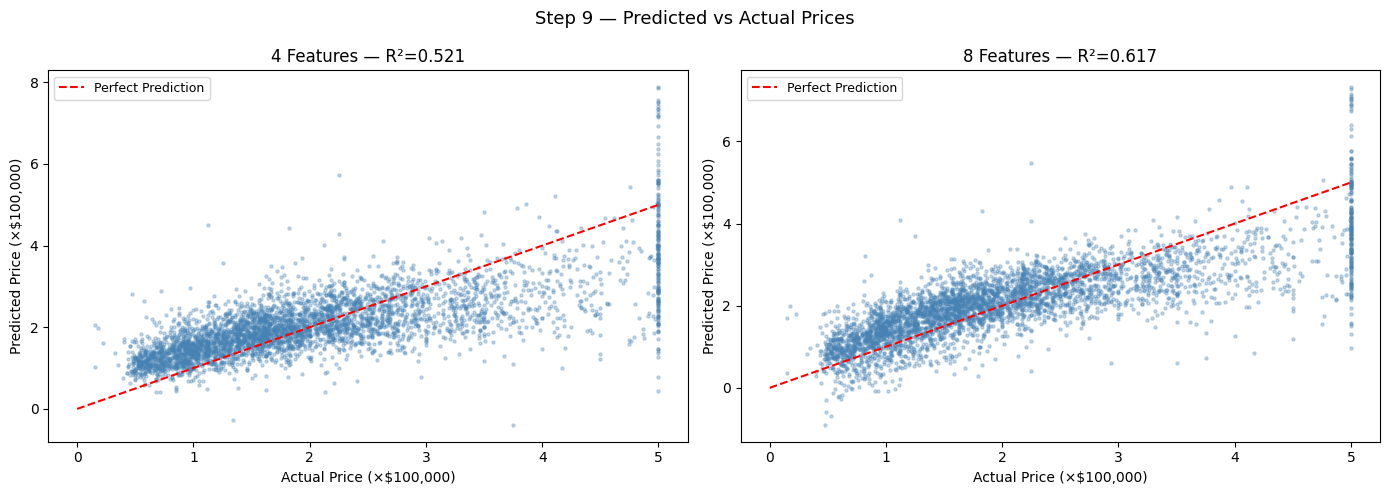


✅ All steps complete. Plots saved as PNG files.


In [13]:
# ─────────────────────────────────────────────
# STEP 9: Visualization — Predicted vs Actual
# A perfect model would have all points on the red diagonal line.
# Points scattered around the line show prediction errors.
# ─────────────────────────────────────────────
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Step 9 — Predicted vs Actual Prices", fontsize=13)
 
for ax, y_true, y_pred, r2, title in [
    (axes[0], y_test,  y_pred, r2, f"4 Features — R²={r2:.3f}"),
    (axes[1], y_test2, y_pred_2, r2_2, f"8 Features — R²={r2_2:.3f}"),
]:
    ax.scatter(y_true, y_pred, alpha=0.3, s=5, color='steelblue')
    ax.plot([0, 5], [0, 5], 'r--', linewidth=1.5, label='Perfect Prediction')
    ax.set_xlabel("Actual Price (×$100,000)")
    ax.set_ylabel("Predicted Price (×$100,000)")
    ax.set_title(title)
    ax.legend(fontsize=9)
 
plt.tight_layout()
plt.savefig("prediction_plots.png", dpi=150)
plt.show()
 
print("\n✅ All steps complete. Plots saved as PNG files.")